# Hafta 2 · Ders 3 — Sıfırdan Evrişim

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Bu, tüm alanın üzerine kurulduğu işlemdir. **Evrişim (convolution)**, küçük bir diziyi —
**çekirdeği (kernel)** — bir görüntü boyunca kaydırarak her komşuluğun ağırlıklı toplamını hesaplar.
Ağırlıkları seçin, bulanıklaştırma, keskinleştirme, kenar tespiti, kabartma elde edersiniz — ve
ağırlıklar *öğrenildiğinde* bir evrişimli sinir ağı.

Evrişimi dikkatlice türetiyoruz (onu korelasyondan ayıran çevirme dahil), sıfırdan uyguluyoruz,
kenarları ele alıyoruz, hız için **ayrılabilirlikten (separability)** yararlanıyoruz ve `scipy`'a
karşı doğruluyoruz. Hafta 3–6'daki her şey burada inşa ettiğimizin özel bir halidir.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve as scipy_convolve
from utils.cv_utils import show, show_row, sample_gray, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Tanım

$(2a{+}1)\\times(2b{+}1)$ boyutunda bir $K$ çekirdeği için, $I$ görüntüsünün $K$ ile evrişimi şudur:

$$ (I * K)[y, x] = \\sum_{i=-a}^{a}\\sum_{j=-b}^{b} I[y-i,\\, x-j]\\;K[i, j] $$

Görüntü indekslerindeki **eksi işaretlerine** dikkat edin: evrişim, kaydırmadan önce çekirdeği
*çevirir*. Çevirmeyi atlarsanız **çapraz korelasyon (cross-correlation)** elde edersiniz — ikisi
simetrik çekirdekler (Gauss gibi) için aynıdır ama asimetrik olanlar için farklıdır. Derin
öğrenmenin "evrişim" katmanları aslında korelasyondur; hangisinin hangisi olduğu konusunda kesin
olacağız.

[PASS] convolve2d vs scipy                max|Δ| = 0.00e+00


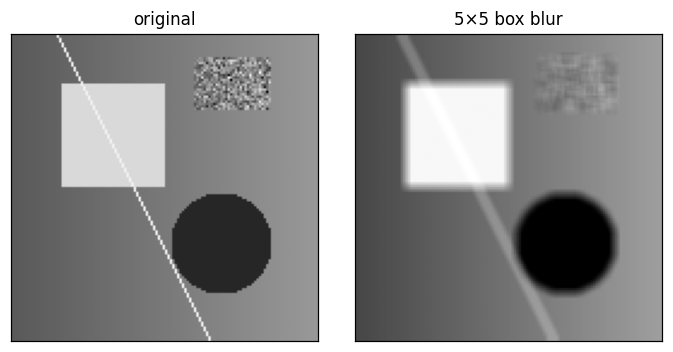

In [2]:
def convolve2d(image, kernel, pad="reflect"):
    image = np.asarray(image, float)
    kernel = np.asarray(kernel, float)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    kflip = kernel[::-1, ::-1]                    # çevirme → gerçek evrişim
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode=pad)
    out = np.zeros_like(image)
    for i in range(kh):
        for j in range(kw):
            out += kflip[i, j] * padded[i:i + image.shape[0], j:j + image.shape[1]]
    return out

img = sample_gray(128)
# basit bir ortalama (kutu) çekirdeği
box = np.ones((5, 5)) / 25
blurred = convolve2d(img, box)

check("convolve2d vs scipy", blurred, scipy_convolve(img, box, mode="mirror"))
show_row([img, blurred], ["orijinal", "5×5 kutu bulanıklığı"])
plt.show()

## 2. Korelasyon vs evrişim — çevirme önemlidir

Farkı **asimetrik** bir çekirdekle görünür kılalım. Evrişim onu çevirir; korelasyon çevirmez.
Görüntüyü kaydıran bir çekirdek için ikisi ayna-zıttı kaymalar üretir.

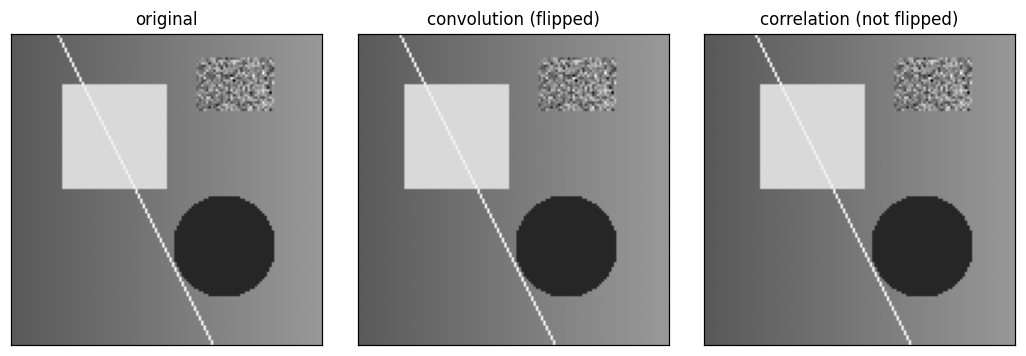

convolution and correlation shift the image in OPPOSITE directions for asymmetric kernels.


In [3]:
def correlate2d(image, kernel, pad="reflect"):
    # convolve2d ile aynı ama çekirdek çevirmesi OLMADAN
    return convolve2d(image, kernel[::-1, ::-1], pad)   # iç çevirmeyi geri al

# asimetrik bir kaydırma çekirdeği
shift = np.zeros((1, 5)); shift[0, 0] = 1.0

conv = convolve2d(img, shift)
corr = correlate2d(img, shift)
show_row([img, conv, corr], ["orijinal", "evrişim (çevrilmiş)", "korelasyon (çevrilmemiş)"])
plt.show()
print("evrişim ve korelasyon, asimetrik çekirdekler için görüntüyü ZIT yönlerde kaydırır.")

## 3. Elle tasarlanmış çekirdeklerden bir galeri

Evrişimin gücü, *tek bir* işlemin yalnızca ağırlıkları değiştirerek çılgınca farklı etkiler
üretmesidir. İşte klasikler — her biri, derin öğrenmeden onlarca yıl önce mühendislerin elle
tasarladığı bir $3\\times3$ çekirdek.

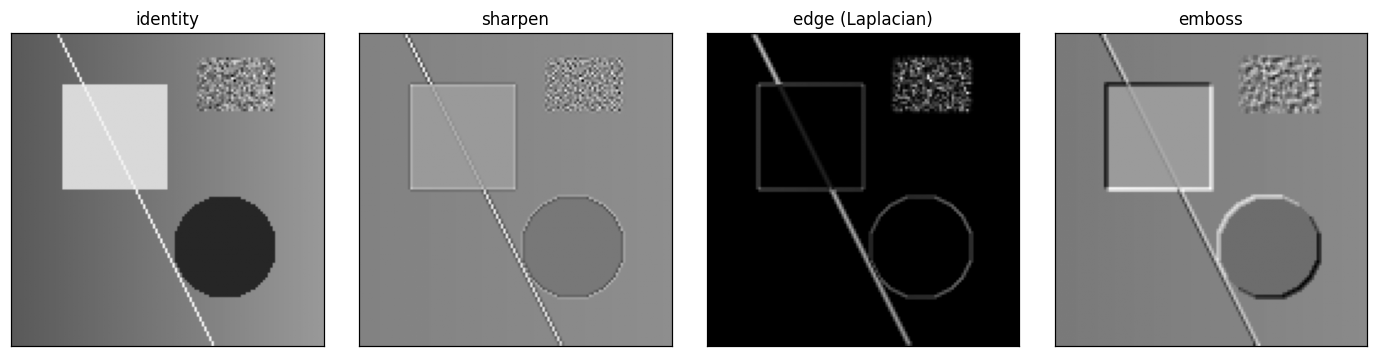

In [4]:
kernels = {
    "özdeşlik":  np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    "keskinleştir":   np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    "kenar (Laplas)": np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]),
    "kabartma":    np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]]),
}
results = [convolve2d(img, k) for k in kernels.values()]
# kenar/kabartmayı görüntüleme için normalize et
disp = [results[0], results[1],
        np.abs(results[2]) / (np.abs(results[2]).max() + 1e-9),
        (results[3] - results[3].min()) / (np.ptp(results[3]) + 1e-9)]
show_row(disp, list(kernels.keys()))
plt.show()

## 4. Ayrılabilir çekirdekler: $O(k^2)\\to O(k)$ hızlandırması

Bazı 2B çekirdekler **ayrılabilirdir**: iki 1B çekirdeğin dış çarpımına ayrışırlar,
$K = \\mathbf{c}\\,\\mathbf{r}^\\top$. O zaman $K$ ile evrişim, satırlar boyunca $\\mathbf{r}$ ile,
ardından sütunlar boyunca $\\mathbf{c}$ ile evrişime eşittir. $k\\times k$ ayrılabilir bir filtre,
piksel başına $k^2$ yerine $2k$ çarpmaya mal olur — büyük bir kazanç ve Gauss bulanıklığının hızlı
olmasının nedeni. Kutu ve Gauss filtrelerinin ikisi de ayrılabilirdir.

In [5]:
def convolve_separable(image, col_kernel, row_kernel, pad="reflect"):
    tmp = convolve2d(image, row_kernel.reshape(1, -1), pad)   # satırlar boyunca
    return convolve2d(tmp, col_kernel.reshape(-1, 1), pad)    # sütunlar boyunca

# 5×5 kutu (1/5 birler) ⊗ (1/5 birler) olarak ayrışır
ones5 = np.ones(5) / 5
sep = convolve_separable(img, ones5, ones5)
full = convolve2d(img, np.ones((5, 5)) / 25)
check("ayrılabilir == tam kutu bulanıklığı", sep, full)

# bir Gauss'un da ayrılabilir olduğunu doğrula
g1 = np.exp(-np.linspace(-2, 2, 5)**2 / 2); g1 /= g1.sum()
G = np.outer(g1, g1)
check("Gauss rank-1'dir (ayrılabilir): K == c rᵀ", G, np.outer(g1, g1))
print("Gauss çekirdeğinin tekil değerleri:", np.linalg.svd(G, compute_uv=False).round(4))
print("→ yalnızca bir sıfır-olmayan tekil değer ⇒ rank 1 ⇒ ayrılabilir.")

[PASS] separable == full box blur         max|Δ| = 3.33e-16
[PASS] Gaussian is rank-1 (separable): K == c rᵀ max|Δ| = 0.00e+00
singular values of the Gaussian kernel: [0.287 0.    0.    0.    0.   ]
→ only one non-zero singular value ⇒ rank 1 ⇒ separable.


## 5. Kenarlar: kenarda ne olur?

Çekirdek, kenarlarda görüntünün dışına sarkar, dolayısıyla orada değerler uydurmamız gerekir.
Yaygın stratejiler: **sıfır-dolgu (zero-padding)** (karanlık hale), **yansıtma (reflect)** (görüntüyü
aynala), **çoğaltma (replicate)** (kenar pikselini tekrarla), **sarma (wrap)** (döşe). Seçim farklı
kenar bozulmaları yaratır — en net şekilde güçlü bir bulanıklıkla görülür.

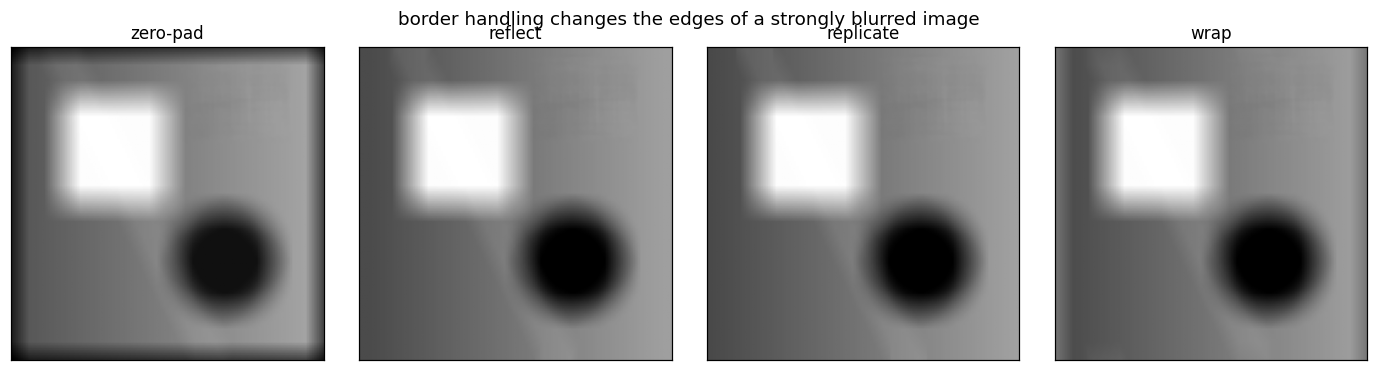

In [6]:
strong = np.ones((15, 15)) / 225
modes = ["constant", "reflect", "edge", "wrap"]
names = ["sıfır-dolgu", "yansıtma", "çoğaltma", "sarma"]
outs = [convolve2d(img, strong, pad=m) for m in modes]
show_row(outs, names)
plt.suptitle("kenar işleme, güçlü bulanıklaştırılmış bir görüntünün kenarlarını değiştirir", y=1.04)
plt.show()

## 6. Bunun modern görüde nerede karşımıza çıktığı

- **CNN'ler öğrenilmiş evrişim yığınlarıdır.** Bir evrişim katmanı, ağırlıkları tasarlanmaktan
  ziyade *eğitilen* birçok küçük çekirdek uygular — ama kaydırmalı-ağırlıklı-toplam işlemi tam olarak
  bu notebook'un `convolve2d`'sidir (teknik olarak korelasyon, §2'ye göre).
- **Ayrılabilirlik bir mimari hilesidir.** Derinlik-bazlı ayrılabilir evrişimler (MobileNet),
  pahalı bir evrişimi ucuz parçalara ayırır — aynı $k^2 \\to k$ fikri, öğrenilmiş haliyle.
- **Dolgu (padding) bir hiperparametredir.** Her çerçevedeki "same" vs "valid" dolgusu, §5'teki
  kenar seçimidir.

Önizleme: iki basit evrişimi yığmak zaten kaba bir öznitelik dedektörü oluşturur — bir CNN'in tohumu.

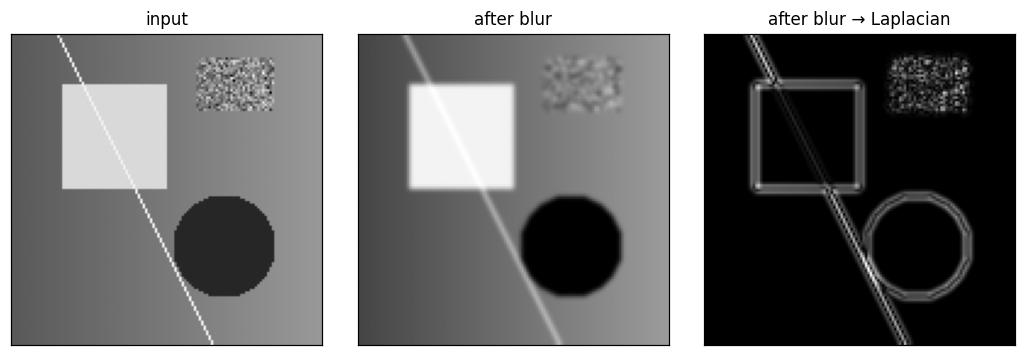

Two stacked convolutions = a tiny hand-wired feature extractor. Week 6 makes the weights learnable.


In [7]:
# evrişim 1: bulanıklaştır (gürültüyü bastır) → evrişim 2: Laplas (kenarları bul). Çekirdeklerin bileşimi.
g = np.exp(-np.linspace(-2, 2, 5)**2 / 2); g /= g.sum()
smoothed = convolve_separable(img, g, g)
edges = convolve2d(smoothed, np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]))
show_row([img, smoothed, np.abs(edges)], ["giriş", "bulanıklaştırma sonrası", "bulanıklaştırma → Laplas sonrası"])
plt.show()
print("İki yığılmış evrişim = küçük, elle bağlanmış bir öznitelik çıkarıcı. Hafta 6 ağırlıkları öğrenilebilir yapar.")

## Alıştırmalar

1. **Hareket bulanıklığı.** Yatay hareket bulanıklığını simüle eden bir çekirdek tasarla (eşit ağırlıklı 1×k satırı). Uygula ve sonucu açıkla.
2. **Keskinleştirme = özdeşlik + kenarlar.** Keskinleştirme çekirdeğinin özdeşlik artı ölçeklenmiş bir Laplas'a eşit olduğunu göster. Bir λ için `sharpen(I) == I + λ·Laplacian(I)` olduğunu sayısal olarak doğrula.
3. **Değişme özelliği.** Evrişim birleşmeli ve değişmelidir. Bulanıklaştırıp sonra keskinleştirmenin ≈ keskinleştirip sonra bulanıklaştırmaya eşit olduğunu (kenar etkilerine kadar) doğrula.

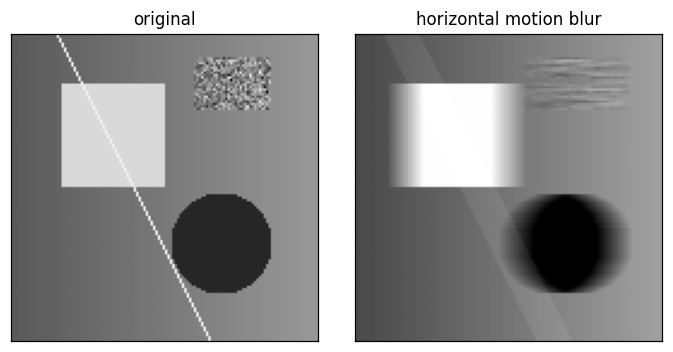

[PASS] sharpen == identity − Laplacian    max|Δ| = 0.00e+00


True

In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. hareket bulanıklığı = 1×k ortalama satırı
motion = np.ones((1, 15)) / 15
show_row([img, convolve2d(img, motion)], ["orijinal", "yatay hareket bulanıklığı"])
plt.show()

# 2. keskinleştirme = özdeşlik + Laplas ([[0,1,0],[1,-4,1],[0,1,0]] formunda λ = -1 ile)
ident = np.array([[0,0,0],[0,1,0],[0,0,0]])
lap   = np.array([[0,1,0],[1,-4,1],[0,1,0]])
sharpen = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
check("keskinleştir == özdeşlik − Laplas", sharpen, ident - lap)

## Özet ve sırada ne var

Evrişim, bir çekirdeği görüntü üzerinde ağırlıklı bir komşuluk toplamı olarak kaydırır; çevirme onu
korelasyondan ayırır; ayrılabilir çekirdekler ucuzdur; kenarlar bir dolgu stratejisi gerektirir.
Tek bir işlem, sonsuz filtre — ve CNN'lerin temeli.

**Sırada — `04_smoothing_gaussian_filters.ipynb`:** hepsinin en önemli çekirdeği olan **Gauss**'a
odaklanıyoruz, özelliklerini türetiyoruz, gürültüyü gidermek için kullanıyoruz ve kursun ilerleyen
kısmında damla ve öznitelik tespitini güçlendiren ölçek-uzayını (scale-space) inşa ediyoruz.

---
*Bilgisayarlı Görü · Hafta 2 · Ders 3*